Import Libraries

In [1]:
import jax
import flax
import optax
from jax import lax, random, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from flax import linen as nn
from evojax.util import get_params_format_fn

import time
import numpy as np
import pandas as pd
from scipy import io
import matplotlib.pyplot as plt

# choose GPU
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '1'
#jax.config.update("jax_enable_x64", True)
jax.config.update("jax_default_matmul_precision", "highest")

In [2]:
# parameter
# Ra = 1e7
Pr = 0.71
Ra = 1e7

theta = jnp.sqrt(Pr/Ra)
theta

2025-09-08 18:27:38.402391: W external/xla/xla/service/gpu/nvptx_compiler.cc:763] The NVIDIA driver's CUDA version is 12.4 which is older than the ptxas CUDA version (12.6.77). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


Array(0.00026646, dtype=float32, weak_type=True)

In [3]:
Gr = jnp.sqrt(Pr*Ra)
1/Gr


Array(0.00037529, dtype=float32, weak_type=True)

In [4]:
sim = pd.read_csv('xyuvT_1e7.csv')

sim

,X,Y,U,V,T,Unnamed: 5
0,0.0000,0.0,0.0,0.0,1.000000,NaN
1,0.0025,0.0,0.0,0.0,0.903174,NaN
2,0.0075,0.0,0.0,0.0,0.716393,NaN
3,0.0125,0.0,0.0,0.0,0.556398,NaN
4,0.0175,0.0,0.0,0.0,0.433440,NaN
...,...,...,...,...,...,...
40799,0.9825,1.0,0.0,0.0,0.566546,NaN
40800,0.9875,1.0,0.0,0.0,0.443591,NaN
40801,0.9925,1.0,0.0,0.0,0.283599,NaN
40802,0.9975,1.0,0.0,0.0,0.096824,NaN


In [5]:
sim_x = sim['X'].values.reshape(-1,1)
sim_y = sim['Y'].values.reshape(-1,1)
sim_u = sim['U'].values.reshape(-1,1)
sim_v = sim['V'].values.reshape(-1,1)
# sim_p = sim['p'].values.reshape(-1,1)
sim_T = sim['T'].values.reshape(-1,1)
# sim_u, sim_v, sim_p = sim_u/ jnp.sqrt(Pr*Ra), sim_v/ jnp.sqrt(Pr*Ra), sim_p/(Pr*Ra)
x_l, x_u, y_l, y_u = np.min(sim_x), np.max(sim_x), np.min(sim_y), np.max(sim_y)
ext = [x_l, x_u, y_l, y_u]
print (x_l, x_u, y_l, y_u)

data_X, data_Y = np.hstack([sim_x, sim_y]), np.hstack([sim_u, sim_v,sim_T])
print (data_X.shape, data_Y.shape)
# dx & dy
# dx = dy = 1 / (255)
dx = dy = sim_x[2] - sim_x[1]
print (dx, dy)

# exclude corner points
corners = (sim['X'] == x_l) & (sim['Y'] == y_u) | (sim['X'] == x_u) & (sim['Y'] == y_u) | (sim['X'] == x_l) & (sim['Y'] == y_l) | (sim['X'] == x_u) & (sim['Y'] == y_l)
data_X, data_Y = data_X[~corners], data_Y[~corners]

# pressure ref
x_ref, y_ref = np.unique(sim_x), np.unique(sim_y)
x_ref, y_ref = np.take(x_ref, x_ref.size //2), np.take(y_ref, y_ref.size //2)
print (x_ref, y_ref)

# split into BC data
bc = (data_X[:,0] == x_l) | (data_X[:,0] == x_u) | (data_X[:,1] == y_l) | (data_X[:,1] == y_u)

data_X_BC, data_Y_BC = data_X[bc], data_Y[bc]
data_X = data_X[~bc]
data_Y = data_Y[~bc]
print (data_X.shape, data_Y.shape, data_X_BC.shape, data_Y_BC.shape)

0.0 1.0 0.0 1.0
(40804, 2) (40804, 3)
[0.005] [0.005]
0.5025 0.5025
(40000, 2) (40000, 3) (800, 2) (800, 3)


In [6]:
sim_v.max()

0.26114

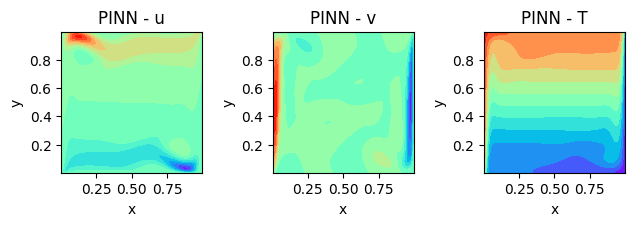

In [7]:
# plot
fig = plt.figure(figsize=(10, 5))
con_lv = 15
ax1 = fig.add_subplot(2,4,1,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,0], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y');plt.title('PINN - u');
ax1 = fig.add_subplot(2,4,2,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,1], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN - v');
ax1 = fig.add_subplot(2,4,3,aspect='equal')
plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,2], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN - T');
# ax1 = fig.add_subplot(2,4,4,aspect='equal')
# plt.tricontourf(data_X[:,0], data_X[:,1], data_Y[:,3], con_lv, origin='lower', cmap='rainbow', extent=ext); plt.xlabel('x'); plt.ylabel('y'); plt.title('PINN - T');
# enlarge the gap between plots
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

In [8]:
# convert to jnp
data_X, data_Y, data_X_BC, data_Y_BC = jnp.array(data_X), jnp.array(data_Y), jnp.array(data_X_BC), jnp.array(data_Y_BC)
print (data_X.shape, data_Y.shape, data_X_BC.shape, data_Y_BC.shape)

(40000, 2) (40000, 3) (800, 2) (800, 3)


DNN / PINN   

In [9]:
nn_acf = nn.silu

class PINN(nn.Module):
    """PINNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                    nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitT = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerT = [nn_acf,
                          nn.Dense(n_nodes, kernel_init = kinit),
                          nn_acf,
                          nn.Dense(n_nodes, kernel_init = kinit),
                          nn_acf,
                          nn.Dense(1, kernel_init = kinit, use_bias=False),
                          ]

    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
        def get_uvp(x, y):
            inputs = jnp.hstack([x,y])
            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(2*jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)
            T = self.splitT(hidden)
            for i, lyr in enumerate(self.layerT):
                T = lyr(T)
            return (u, v, p,T)

        u, v, p,T = get_uvp(x, y)


        # axillary PDE outputs
        # discretization (1st order)
        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE, TE = get_uvp(xE, y)
        uW, vW, pW, TW = get_uvp(xW, y)
        uN, vN, pN, TN = get_uvp(x, yN)
        uS, vS, pS, TS = get_uvp(x, yS)
        ue, ve, pe, Te = get_uvp(xe, y)
        uw, vw, pw, Tw = get_uvp(xw, y)
        un, vn, pn, Tn = get_uvp(x, yn)
        us, vs, ps, Ts = get_uvp(x, ys)


        uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 0, 0
        uSbc, vSbc = 0, 0
        TEbc = 0
        TWbc = 1

        if(bi_count == 1):

            xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
            yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            uE, vE,TE = jnp.where(xB_E, uEbc, uE), jnp.where(xB_E, vEbc, vE), jnp.where(xB_E, TEbc, TE)
            uW, vW,TW = jnp.where(xB_W, uWbc, uW), jnp.where(xB_W, vWbc, vW), jnp.where(xB_W, TWbc, TW)
            uN, vN,TN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN), jnp.where(yB_N, T, TN)
            uS, vS,TS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS), jnp.where(yB_S, T, TS)
            ### div = (ue - uw) + (vn - vs)
            ### div = (uE - uW + vN - vS)/2
        if(bi_count == 1):

            xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
            yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            ue, ve,Te = jnp.where(xB_e, uEbc, ue), jnp.where(xB_e, vEbc, ve),jnp.where(xB_e, TEbc, Te)
            uw, vw,Tw = jnp.where(xB_w, uWbc, uw), jnp.where(xB_w, vWbc, vw), jnp.where(xB_w, TWbc, Tw)
            un, vn,Tn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn), jnp.where(yB_n, T, Tn)
            us, vs,Ts = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs), jnp.where(yB_s, T, Ts)
        # if

        ae = ue
        aw = -uw
        an = vn
        aas = -vs

        source_x = (pe - pw)
        source_y = (pn - ps)- T*dx

        bc  = (x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)
        nbc = (~bc)
        bc_left_right = (x == x_u) | (x == x_l)
        bc_top = (y == y_u )
        bc_bottom = (y == y_l )

        top_T= T -Ts
        bottom_T= T -Tn

        div = (ue - uw) + (vn - vs)
        # div = (uE - uW + vN - vS)/2


        mom_x = ae*ue + aw*uw + an*un + aas*us + source_x - (uE + uW + uN + uS - 4*u)/(dx)*theta 
        mom_y = ae*ve + aw*vw + an*vn + aas*vs + source_y - (vE + vW + vN + vS - 4*v)/(dx)*theta 
        energy = ae*Te + aw*Tw + an*Tn + aas*Ts - (TE + TW + TN + TS - 4*T)/(dx*Gr) 

        res_u = ( source_x - (uE + uW + uN + uS)/(dx)*theta)/dx 
        res_v = ( source_y - (vE + vW + vN + vS)/(dx)*theta)/dx
        res_T = (  - (TE + TW + TN + TS)/(dx*Gr))/dx

        residuals_continuity = div/dx
        residuals_momentum_1 = mom_x/dx
        residuals_momentum_2 = mom_y/dy
        residuals_energy = energy/dx


        outputs = jnp.hstack([u, v, p,T, residuals_continuity, residuals_momentum_1, residuals_momentum_2,residuals_energy, bc, nbc,res_u,res_v,res_T,top_T,bottom_T,bc_left_right,bc_top,bc_bottom])
        return outputs

class DNN(nn.Module):
    """DNNs"""
    def setup(self):
        # initialization
        kinit = jax.nn.initializers.he_uniform()
        # feature mapping later
        self.feats = nn.Dense(n_nodes * 2, kernel_init = kinit)
        # hidden layers
        self.layers = [nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf]
        # split layers
        self.splitu = nn.Dense(n_nodes, kernel_init = kinit)
        self.layeru = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitv = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerv = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitp = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerp = [nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(n_nodes, kernel_init = kinit),
                       nn_acf,
                       nn.Dense(1, kernel_init = kinit, use_bias=False),
                       ]
        self.splitT = nn.Dense(n_nodes, kernel_init = kinit)
        self.layerT = [nn_acf,
                          nn.Dense(n_nodes, kernel_init = kinit),
                          nn_acf,
                          nn.Dense(n_nodes, kernel_init = kinit),
                          nn_acf,
                          nn.Dense(1, kernel_init = kinit, use_bias=False),
                          ]

    @nn.compact
    def __call__(self, inputs):
        # split the two variables, probably just by slicing
        x, y = inputs[:,0:1], inputs[:,1:2]
        def get_uvp(x, y):
            inputs = jnp.hstack([x,y])
            # feature mapping
            hidden = self.feats(inputs)
            hidden = jnp.sin(2*jnp.pi*hidden)

            # share hidden layer
            for i, lyr in enumerate(self.layers):
                hidden = lyr(hidden)
            # split hidden layer
            u = self.splitu(hidden)
            for i, lyr in enumerate(self.layeru):
                u = lyr(u)
            v = self.splitv(hidden)
            for i, lyr in enumerate(self.layerv):
                v = lyr(v)
            p = self.splitp(hidden)
            for i, lyr in enumerate(self.layerp):
                p = lyr(p)
            T = self.splitT(hidden)
            for i, lyr in enumerate(self.layerT):
                T = lyr(T)
            return (u, v, p,T)

        u, v, p,T = get_uvp(x, y)

       # axillary PDE outputs
        # discretization (1st order)
        xE, xW = x + dx, x - dx
        yN, yS = y + dy, y - dy
        xe, xw = x + 0.5*dx, x - 0.5*dx
        yn, ys = y + 0.5*dy, y - 0.5*dy
        # obtain u, v, p neighbour
        uE, vE, pE, TE = get_uvp(xE, y)
        uW, vW, pW, TW = get_uvp(xW, y)
        uN, vN, pN, TN = get_uvp(x, yN)
        uS, vS, pS, TS = get_uvp(x, yS)
        ue, ve, pe, Te = get_uvp(xe, y)
        uw, vw, pw, Tw = get_uvp(xw, y)
        un, vn, pn, Tn = get_uvp(x, yn)
        us, vs, ps, Ts = get_uvp(x, ys)


        uEbc, vEbc = 0, 0
        uWbc, vWbc = 0, 0
        uNbc, vNbc = 0, 0
        uSbc, vSbc = 0, 0
        TEbc = 0
        TWbc = 1


        if(bi_count == 1):

            xB_E, xB_W = abs(xE-x_u)<0.01*dx, abs(xW-x_l)<0.01*dx
            yB_N, yB_S = abs(yN-y_u)<0.01*dy, abs(yS-y_l)<0.01*dy
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            uE, vE,TE = jnp.where(xB_E, uEbc, uE), jnp.where(xB_E, vEbc, vE), jnp.where(xB_E, TEbc, TE)
            uW, vW,TW = jnp.where(xB_W, uWbc, uW), jnp.where(xB_W, vWbc, vW), jnp.where(xB_W, TWbc, TW)
            uN, vN,TN = jnp.where(yB_N, uNbc, uN), jnp.where(yB_N, vNbc, vN), jnp.where(yB_N, T, TN)
            uS, vS,TS = jnp.where(yB_S, uSbc, uS), jnp.where(yB_S, vSbc, vS), jnp.where(yB_S, T, TS)

        if(bi_count == 1):

            xB_e, xB_w = abs(xe-x_u)<0.01*dx, abs(xw-x_l)<0.01*dx
            yB_n, yB_s = abs(yn-y_u)<0.01*dy, abs(ys-y_l)<0.01*dy
            # direct forcing u & v values for xB_E, xB_W, yB_N, yB_S
            ue, ve,Te = jnp.where(xB_e, uEbc, ue), jnp.where(xB_e, vEbc, ve),jnp.where(xB_e, TEbc, Te)
            uw, vw,Tw = jnp.where(xB_w, uWbc, uw), jnp.where(xB_w, vWbc, vw), jnp.where(xB_w, TWbc, Tw)
            un, vn,Tn = jnp.where(yB_n, uNbc, un), jnp.where(yB_n, vNbc, vn), jnp.where(yB_n, T, Tn)
            us, vs,Ts = jnp.where(yB_s, uSbc, us), jnp.where(yB_s, vSbc, vs), jnp.where(yB_s, T, Ts)
        # if




        ae = ue
        aw = -uw
        an = vn
        aas = -vs

        source_x = (pe - pw)
        source_y = (pn - ps)- T*dx

        bc  = (x == x_l) | (x == x_u) | (y == y_l) | (y == y_u)

        div = (ue - uw) + (vn - vs)

        mom_x = ae*ue + aw*uw + an*un + aas*us + source_x - (uE + uW + uN + uS - 4*u)/(dx)*theta 
        mom_y = ae*ve + aw*vw + an*vn + aas*vs + source_y - (vE + vW + vN + vS - 4*v)/(dx)*theta 
        energy = ae*Te + aw*Tw + an*Tn + aas*Ts - (TE + TW + TN + TS - 4*T)/(dx*Gr) 

        residuals_continuity = div/dx
        residuals_momentum_1 = mom_x/dx
        residuals_momentum_2 = mom_y/dy
        residuals_energy = energy/dx


        res_u = ( source_x - (uE + uW + uN + uS)/(dx)*theta )/dx
        res_v = ( source_y - (vE + vW + vN + vS)/(dx)*theta )/dx
        res_T = (  - (TE + TW + TN + TS)/(dx*Gr))/dx

        #shift p_ref
        x_pref, y_pref = jnp.ones_like(x)*x_ref,jnp.ones_like(y)*y_ref
        _, _, pref,_ = get_uvp(x_pref,y_pref)

        pout = p - pref

        outputs = jnp.hstack([u, v, pout,T,residuals_momentum_1,residuals_momentum_2,residuals_energy,res_u,res_v,res_T])
        return outputs


In [10]:
# choose seed
seed = 10
key, rng = random.split(random.PRNGKey(seed))

# dummy input
a = random.normal(key, [1,2])

# initialization call
bi_count = 1
n_nodes = 32
model, model_0 = PINN(), DNN()
params = model.init(key, a)
num_params, format_params_fn = get_params_format_fn(params)
print (num_params)

# flatten initial params
params = jax.flatten_util.ravel_pytree(params)[0]

params_0 = params

16128


In [11]:
# minibatch (set #sample)
BS_ALL = int(len(data_X)*0.1)
BS_BC = int(len(data_X_BC)*0.1)

BS_PDE = BS_ALL
n_all, n_bc = len(data_X), len(data_X_BC)
print(BS_ALL, BS_BC)
@jit
def minibatch(key):
    batch_all = random.choice(key, n_all, (BS_PDE,),replace = False)
    batch_bc = random.choice(key, n_bc, (BS_BC,),replace = False)
    batch_X = jnp.vstack([data_X[batch_all], data_X_BC[batch_bc]])
    batch_Y = jnp.vstack([data_Y[batch_all], data_Y_BC[batch_bc]])
    return (batch_X, batch_Y)

4000 80


In [12]:
# loss function
def eval_loss(params,params_0, inputs, labels):
    pred = model.apply(format_params_fn(params), inputs)

    u, v, p,T, residuals_continuity, residuals_momentum_1, residuals_momentum_2,residuals_energy, bc, nbc,res_u,res_v,res_T,top_T,bottom_T,bc_left_right,bc_top,bc_bottom = jnp.split(pred, 18, axis=1)
    gt_u, gt_v,gt_T = jnp.split(labels, 3, axis=1)
    # stable evolution
    # PDE
    pred0 = model_0.apply(format_params_fn(params_0), inputs)
    u_0, v_0, p_0,T_0,residuals_momentum_10,residuals_momentum_20,residuals_energy0,res_u0,res_v0,res_T0 = jnp.split(pred0, 10, axis=1)
    beta = 0.82
    beta_v = 0.82
    beta_T = 0.82

    loss_u = u - (beta*(-residuals_momentum_1 + res_u0 - res_u)*dx*dx/(4*theta)) - u_0
    loss_v = v - (beta*(-residuals_momentum_2 + res_v0 - res_v)*dx*dx/(4*theta)) - v_0
    loss_T = T - (beta*(-residuals_energy + res_T0 - res_T)*dx*dx*Gr/4) - T_0

    alpha_u = 1.0
    alpha_v = 1.0
    alpha_T = 1.0

    pde_uvp  = jnp.square(residuals_continuity) + jnp.square(residuals_momentum_1) + jnp.square(residuals_momentum_2) + jnp.square(residuals_energy) +  alpha_u*jnp.abs(loss_u) + alpha_v*jnp.abs(loss_v)  + alpha_T*jnp.abs(loss_T)
    pde_loss = jnp.sum(pde_uvp*nbc) / nbc.sum()
    # BC
    bc_u = (u - gt_u)
    bc_v = (v - gt_v)
    bc_T = (T - gt_T)

    T_loss_rl = jnp.sum((jnp.square(bc_T)*bc_left_right)) / bc_left_right.sum()
    T_loss_top = jnp.sum((jnp.square(top_T)*bc_top)) / bc_top.sum()
    T_loss_bottom = jnp.sum((jnp.square(bottom_T)*bc_bottom)) / bc_bottom.sum()
    T_loss = T_loss_rl + T_loss_top + T_loss_bottom


    bc_uv   = jnp.square(bc_u) + jnp.square(bc_v)
    bc_loss_ = jnp.sum(bc_uv*bc) / bc.sum()
    bc_loss = bc_loss_ + T_loss
    # mse
    uv = jnp.hstack([u, v])
    gt_uv = jnp.hstack([gt_u, gt_v])
    mse = jnp.mean(jnp.square(uv - gt_uv))
    uvrl2 = jnp.linalg.norm(uv - gt_uv) / jnp.linalg.norm(gt_uv)
    preV = jnp.sqrt(jnp.square(u) + jnp.square(v))
    gtV = jnp.sqrt(jnp.square(gt_u) + jnp.square(gt_v))
    Vrl2 = jnp.linalg.norm(preV - gtV) / jnp.linalg.norm(gtV)
    Trl2 = jnp.linalg.norm(T - gt_T) / jnp.linalg.norm(gt_T)
    rl2 = (Vrl2 + Trl2)
    loss = pde_loss*1 + 1*bc_loss
    return loss, (mse, rl2,Vrl2,Trl2,pde_loss, bc_loss)

loss_grad = jax.jit(jax.value_and_grad(eval_loss, has_aux=True))

In [13]:
# weights update
@jit
def update(params, params_0,opt_state, key):
    batch_X, batch_Y = minibatch(key)
    (loss, (mse, rl2,uvrl2,Trl2,pde_loss,bc_loss)), grad = loss_grad(params,params_0, batch_X, batch_Y)
    updates, opt_state = optimizer.update(grad, opt_state)
    params_0 = params # update u_0

    params = optax.apply_updates(params, updates)
    return params, params_0,opt_state, loss, mse, rl2,uvrl2,Trl2, pde_loss, bc_loss

In [14]:
# optimizer
max_iters = 50000
max_lr = 5e-3
lr_scheduler = optax.warmup_cosine_decay_schedule(init_value=max_lr, peak_value=max_lr, warmup_steps=int(0.4*max_iters),
                                                  decay_steps=max_iters, end_value=1e-10,exponent=0.5)
optimizer = optax.adam(learning_rate=lr_scheduler) # Choose the method
opt_state = optimizer.init(params)

Training

In [15]:
# training iteration
runtime = 0
train_iters = 0

store = []
while (train_iters <= max_iters):
    # mini-batch update
    start = time.time()
    key, rng = random.split(rng) # update random generator
    params,params_0, opt_state, loss, mse, rl2,uvrl2,Trl2,pde_loss,bc_loss= update(params,params_0, opt_state, key)
    end = time.time()
    runtime += (end-start)
    # append weights
    if (train_iters % 2000 == 0):
        print ('iter. = %05d,  time = %03ds,  loss = %.2e  |  mse = %.2e,  rl2 = %.2e  ,uvrl2 = %.2e  ,Trl2 = %.2e  , pde =  %.2e, bc = %.2e '%(train_iters, runtime, loss, mse, rl2,uvrl2,Trl2,pde_loss,bc_loss))
        store.append([train_iters, runtime, loss, mse, rl2])
    train_iters += 1

store = jnp.array(store)

iter. = 00000,  time = 013s,  loss = 2.66e+02  |  mse = 1.76e-01,  rl2 = 1.07e+01  ,uvrl2 = 9.27e+00  ,Trl2 = 1.43e+00  , pde =  2.65e+02, bc = 1.26e+00 
iter. = 02000,  time = 021s,  loss = 1.22e-02  |  mse = 1.76e-03,  rl2 = 1.70e+00  ,uvrl2 = 9.34e-01  ,Trl2 = 7.66e-01  , pde =  1.15e-02, bc = 7.29e-04 
iter. = 04000,  time = 029s,  loss = 7.89e-03  |  mse = 1.56e-03,  rl2 = 1.29e+00  ,uvrl2 = 8.85e-01  ,Trl2 = 4.00e-01  , pde =  7.39e-03, bc = 5.01e-04 
iter. = 06000,  time = 038s,  loss = 1.48e-02  |  mse = 1.58e-03,  rl2 = 1.27e+00  ,uvrl2 = 8.59e-01  ,Trl2 = 4.09e-01  , pde =  1.33e-02, bc = 1.51e-03 
iter. = 08000,  time = 046s,  loss = 9.78e-03  |  mse = 7.50e-03,  rl2 = 2.31e+00  ,uvrl2 = 1.94e+00  ,Trl2 = 3.75e-01  , pde =  9.15e-03, bc = 6.25e-04 
iter. = 10000,  time = 055s,  loss = 4.36e-03  |  mse = 3.57e-03,  rl2 = 1.63e+00  ,uvrl2 = 1.30e+00  ,Trl2 = 3.28e-01  , pde =  4.12e-03, bc = 2.40e-04 
iter. = 12000,  time = 063s,  loss = 4.14e-03  |  mse = 7.52e-04,  rl2 = 7.6

PINN solution

In [16]:
# on all tasks
inputs, labels = data_X, data_Y
print(inputs.shape)
uvpT = model.apply(format_params_fn(params), inputs)
u, v, p,T = uvpT[:,0:1], uvpT[:,1:2], uvpT[:,2:3],uvpT[:,3:4]
gt_u, gt_v,gt_T = jnp.split(labels, 3, axis=-1)
uv = jnp.hstack([u, v])
gt_uv = jnp.hstack([gt_u, gt_v])
mse = jnp.mean(jnp.square(uv - gt_uv))
pre_V = jnp.sqrt(jnp.square(u) + jnp.square(v))
gt_V = jnp.sqrt(jnp.square(gt_u) + jnp.square(gt_v))

u_mse = jnp.mean(jnp.square(u - gt_u))
v_mse = jnp.mean(jnp.square(v - gt_v))
T_mse = jnp.mean(jnp.square(T - gt_T))
V_mse = jnp.mean(jnp.square(gt_V - pre_V))

u_rl2 = jnp.linalg.norm(gt_u - u) / jnp.linalg.norm(gt_u)
v_rl2 = jnp.linalg.norm(gt_v - v) / jnp.linalg.norm(gt_v)
V_rl2 = jnp.linalg.norm(pre_V - gt_V) / jnp.linalg.norm(gt_V)
T_RL2 = jnp.linalg.norm(T - gt_T) / jnp.linalg.norm(gt_T)

# rl2 = RL2 + T_RL2
print ('[Ra=%.2e] :  uMSE = %.2e,vMSE = %.2e,TMSE = %.2e,VMSE = %.2e, url2 = %.2e,vrl2 = %.2e, Vrl2 = %.2e,Trl2 = %.2e'%(Ra, u_mse, v_mse, T_mse,V_mse,u_rl2,v_rl2,V_rl2,T_RL2))

(40000, 2)
[Ra=1.00e+07] :  uMSE = 3.47e-06,vMSE = 1.94e-06,TMSE = 9.84e-06,VMSE = 3.82e-06, url2 = 6.18e-02,vrl2 = 2.62e-02, Vrl2 = 3.20e-02,Trl2 = 5.65e-03


In [17]:
# [Ra=1.00e+07] :  uMSE = 3.47e-06,vMSE = 1.94e-06,TMSE = 9.84e-06,VMSE = 3.82e-06, url2 = 6.18e-02,vrl2 = 2.62e-02, Vrl2 = 3.20e-02,Trl2 = 5.65e-03